# Exploratory Data Analysis (EDA) on NYC Taxi Trip Dataset

##  Introduction
This notebook performs **Exploratory Data Analysis (EDA)** on the NYC Taxi Trip Duration dataset.

The dataset contains:
- Pickup & dropoff timestamps
- Passenger count
- Geographic coordinates
- Trip duration

###  Objective
- Understand dataset structure
- Detect data quality issues
- Analyze patterns using visualization
- Extract meaningful insights

###  Tools Used
- Pandas
- NumPy
- Matplotlib

##  Import Required Libraries

We import essential libraries for:
- Data manipulation → Pandas
- Numerical operations → NumPy
- Visualization → Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

The dataset `train.csv` is loaded into a Pandas DataFrame.

In [2]:
df = pd.read_csv("train.csv")
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


##  Dataset Understanding

The dataset contains detailed information about taxi trips in New York City.

###  Key Variables:

- **trip_duration** :Total time of the trip in seconds (Target Variable)
- **pickup_datetime** :Time when the trip started
- **dropoff_datetime** :Time when the trip ended
- **passenger_count** : Number of passengers in the taxi
- **pickup_longitude & pickup_latitude** :Pickup location coordinates
- **dropoff_longitude & dropoff_latitude** :Dropoff location coordinates

###  Purpose:
These variables help analyze:
- Travel patterns
- Traffic behavior
- Passenger trends
- Geographic distribution

In [3]:
df.shape

(1458644, 11)

 The dataset contains a large number of records (~1.4 million).

In [4]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='str')

 Columns include time, location, passengers, and trip duration.

In [5]:
df.dtypes

id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
dtype: object

- Datetime columns need conversion  
- Numeric columns are correctly identified

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


##  Data Quality Investigation

We check:
- Missing values
- Duplicate records
- Invalid or unrealistic values

In [8]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

Identify columns with missing values.

In [9]:
df.duplicated().sum()

np.int64(0)

Check if duplicate rows exist.

In [10]:
df['passenger_count'].value_counts()

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64


Passenger count should be reasonable (usually 1–6).

In [11]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

The dataset initially contained unrealistic values such as very small and very large trip durations, 
as well as invalid passenger counts. These issues were addressed in the data cleaning step.

##  Data Cleaning

After identifying data quality issues, we cleaned the dataset to improve accuracy.

###  Steps Performed:
- Removed trips with **invalid passenger counts (≤ 0)**
- Removed trips with **very small durations (< 60 seconds)**
- Removed trips with **extremely large durations (> 20000 seconds)**

###  Reason:
- The dataset is large, so removing a small number of incorrect records does not affect results.
- Outliers can distort analysis and lead to misleading conclusions.


In [12]:
# Remove invalid passenger counts
df = df[df['passenger_count'] > 0]

# Remove extreme trip durations (outliers)
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 20000)]

**Result:**  
The dataset is now cleaner and more reliable for analysis, although minor variations still exist as expected.

##  Univariate Analysis

We analyze individual variables:
- Trip Duration
- Passenger Count

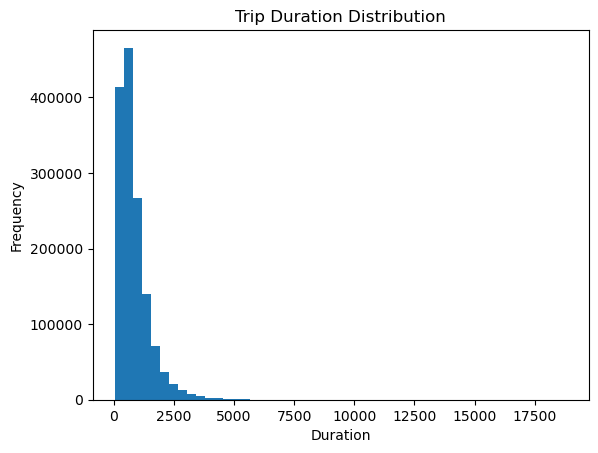

In [13]:
plt.hist(df['trip_duration'], bins=50)
plt.title("Trip Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

**Insight:**  
After removing extreme values, the distribution is still **right-skewed**, meaning most trips are short, 
but a few longer trips still exist. This is normal in real-world transportation data.

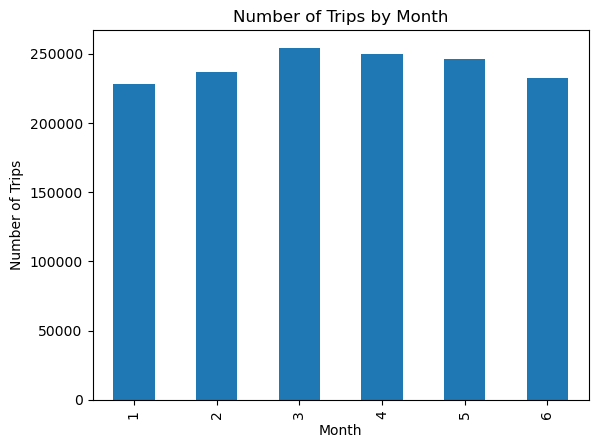

In [26]:
df['month'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.show()

This visualization shows the distribution of taxi trips across different months.

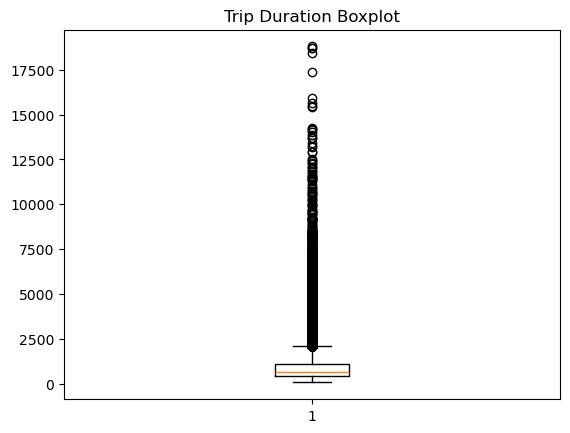

In [14]:
plt.boxplot(df['trip_duration'])
plt.title("Trip Duration Boxplot")
plt.show()

**Insight:**  
After data cleaning, extreme outliers have been removed. However, some minor outliers still remain, 
which is expected in real-world datasets.

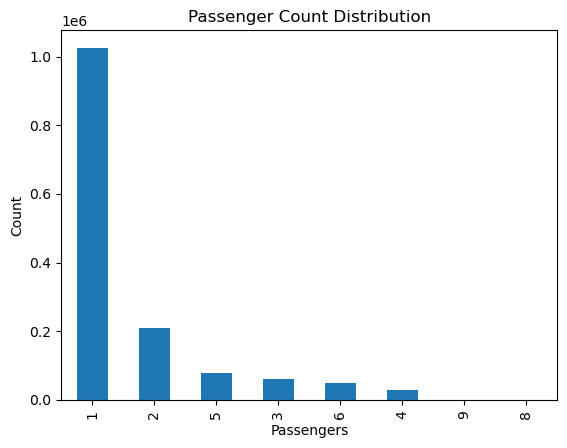

In [15]:
df['passenger_count'].value_counts().plot(kind='bar')
plt.title("Passenger Count Distribution")
plt.xlabel("Passengers")
plt.ylabel("Count")
plt.show()

**Insight:**  
Most trips have 1–2 passengers.

**Insight:**
Trips increase during **morning (7–10 AM)** and **evening (5–8 PM)**, indicating rush hours.
This reflects daily work commute patterns in urban areas.

In [16]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day_name()
df['month'] = df['pickup_datetime'].dt.month

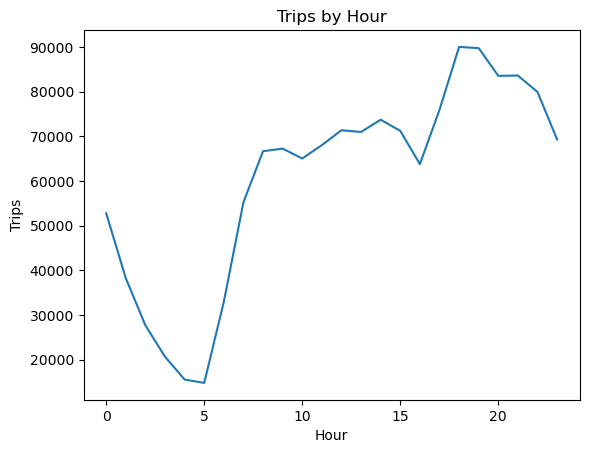

In [17]:
df['hour'].value_counts().sort_index().plot()
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

**Insight:**  
Peak hours occur during morning and evening.

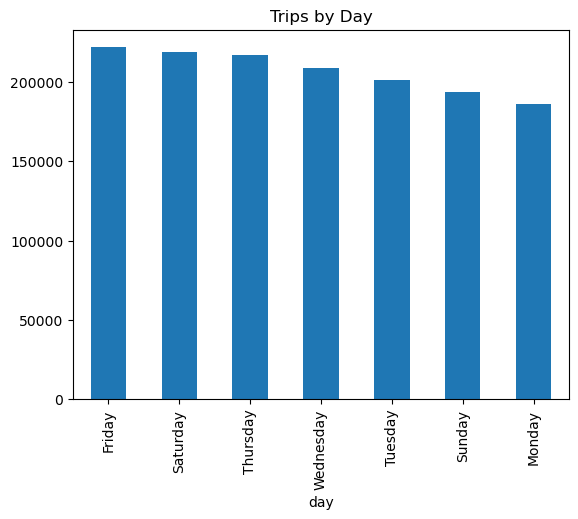

In [18]:
df['day'].value_counts().plot(kind='bar')
plt.title("Trips by Day")
plt.show()

**Insight:**  
Weekdays have more trips than weekends.

##  Spatial Analysis

We analyze pickup locations using coordinates.

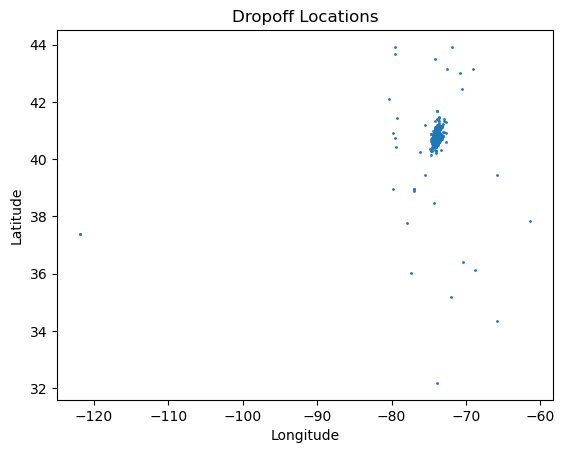

In [19]:
plt.scatter(df['dropoff_longitude'], df['dropoff_latitude'], s=1)
plt.title("Dropoff Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Insight:**
Dropoff points also cluster around specific urban areas, indicating high-demand zones.

##  Relationship Analysis

We explore relationships between variables.

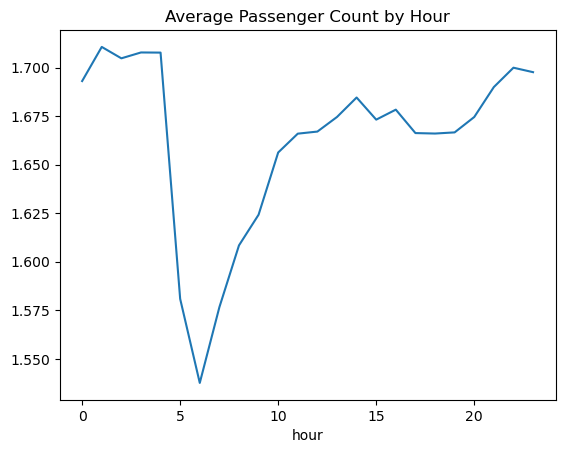

In [20]:
df.groupby('hour')['passenger_count'].mean().plot()
plt.title("Average Passenger Count by Hour")
plt.show()

**Insight:**  
Average trip duration is higher during peak hours, likely due to traffic congestion.  
After removing extreme values, this trend becomes more consistent and realistic.

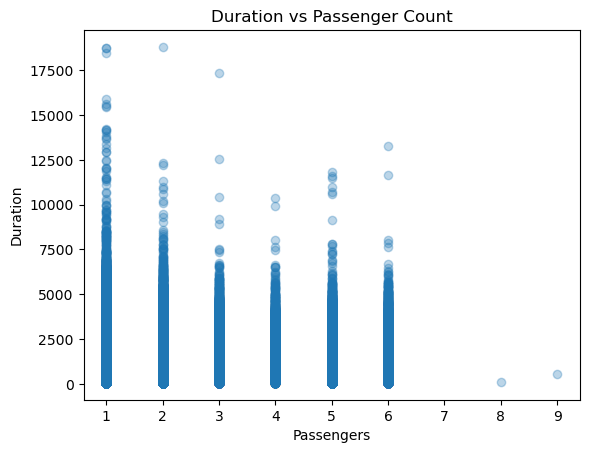

In [21]:
plt.scatter(df['passenger_count'], df['trip_duration'], alpha=0.3)
plt.title("Duration vs Passenger Count")
plt.xlabel("Passengers")
plt.ylabel("Duration")
plt.show()

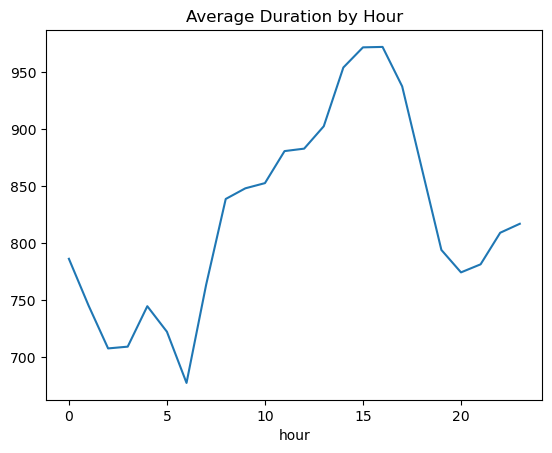

In [22]:
df.groupby('hour')['trip_duration'].mean().plot()
plt.title("Average Duration by Hour")
plt.show()

Trips take longer during peak traffic hours.

##  Aggregated Analysis

We use grouping techniques like:
- groupby
- pivot tables

In [23]:
df.groupby('day')['trip_duration'].mean()

day
Friday       872.165376
Monday       815.187238
Saturday     783.157162
Sunday       768.025135
Thursday     902.575408
Tuesday      860.207017
Wednesday    884.308705
Name: trip_duration, dtype: float64

Average duration varies by day.

In [24]:
pivot = df.pivot_table(values='trip_duration', index='day', columns='hour')
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day,,,,,,,,,,,,,,,,,,,,,
Friday,802.893864,749.772909,703.595128,702.934261,778.786092,746.209877,689.011091,763.783433,853.642232,898.020698,...,1004.097453,1063.601126,1061.288701,967.570201,882.553137,805.933835,801.659783,798.218725,840.676889,869.622642
Monday,724.320094,703.950961,698.524801,725.927453,769.966038,743.329384,693.058047,799.610526,881.626166,883.743966,...,900.947930,913.721262,905.006282,872.946523,803.006831,708.547843,706.717122,725.492086,738.924408,758.736256
Saturday,836.169021,767.313581,726.156319,709.666723,743.924563,787.954707,714.223293,633.296226,631.289895,635.158925,...,823.064869,854.019193,832.063388,853.347865,830.012311,839.052408,809.414932,780.338701,817.198324,836.103382
Sunday,800.586187,775.665986,712.244614,715.071618,729.795803,768.871051,734.777620,653.708066,592.656155,595.976074,...,873.989232,889.765503,890.076221,878.043224,821.420474,777.253562,751.662580,739.877669,738.329154,749.245277
Thursday,748.183087,693.311960,689.564501,714.393045,731.033040,691.485126,667.991665,779.408599,892.537457,928.776796,...,1065.856022,1061.599054,1098.843058,1019.878754,930.619072,838.097268,814.298635,843.600882,867.532898,855.028286
Tuesday,747.616902,697.410889,693.110587,679.590410,747.774309,667.488528,651.269997,780.391352,881.602441,931.218916,...,973.706655,970.225020,978.255046,951.199364,868.014703,766.215949,748.818908,760.659244,797.878040,767.454366
Wednesday,741.304950,693.831616,652.243837,688.133545,720.534091,653.270691,649.911851,776.024582,874.485618,901.255854,...,1030.051752,1053.109994,1069.395647,1020.761089,911.712587,807.480335,774.105251,793.151946,812.498093,802.519636


Shows detailed pattern of duration across day & hour.

##  Visualization Summary

This notebook includes more than **10 visualizations**, including:
- Histograms
- Boxplots
- Bar charts
- Scatter plots
- Line plots

All plots include proper:
- Titles
- Axis labels

#  Key Insights

1. Taxi demand is highest during **morning and evening rush hours**, reflecting daily commuting patterns.

2. After data cleaning, trip duration still shows a **right-skewed distribution**, with most trips being short.

3. The majority of trips involve **1–2 passengers**, indicating individual or small group travel.

4. **Weekdays have higher trip activity** compared to weekends, suggesting work-related travel dominates.

5. Certain geographic areas show **high pickup and dropoff density**, indicating urban hotspots.

6. Trip duration increases during peak hours due to **traffic congestion**.

7. Data cleaning improved the analysis by removing unrealistic values and reducing the impact of extreme outliers.